<a href="https://colab.research.google.com/github/Mr-Faizan-Asim/DeepCore-AI/blob/master/Hackney_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Core
import os, sys, math, warnings
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# Stats & ML
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Display
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
warnings.filterwarnings('ignore')

print('Versions -> pandas:', pd.__version__, '| numpy:', np.__version__)


Versions -> pandas: 2.2.2 | numpy: 2.0.2


## 1. Load Data

In [2]:

# Change this to your file name if needed.
LOCAL_PATH = '/content/Hackney - DataSet.xlsx'  # For Colab
FALLBACK_PATH = 'Hackney - DataSet.xlsx'        # Same folder as notebook

# If running this notebook on my machine (created for you), it's stored at /mnt/data/
CREATED_COPY_PATH = '/mnt/data/Hackney - DataSet.xlsx'

def ensure_file():
    path_candidates = [LOCAL_PATH, FALLBACK_PATH, CREATED_COPY_PATH]
    for p in path_candidates:
        if os.path.exists(p):
            return p
    try:
        from google.colab import files
        print('File not found. Please upload your Excel file (e.g., "Hackney - DataSet.xlsx").')
        uploaded = files.upload()
        name = list(uploaded.keys())[0]
        return name
    except Exception as e:
        raise FileNotFoundError('Could not find the dataset automatically and not in Colab upload mode.') from e

DATA_PATH = ensure_file()
print('Using file:', DATA_PATH)

# Try default sheet; if multiple sheets exist, load the first by default but provide a list
xls = pd.ExcelFile(DATA_PATH)
print('Sheets:', xls.sheet_names)
df = pd.read_excel(DATA_PATH, sheet_name=xls.sheet_names[0])
print('Shape:', df.shape)
df.head()


Using file: /content/Hackney - DataSet.xlsx
Sheets: ['Sheet1']
Shape: (4857, 32)


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_District,Local_Authority_Highway,1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,Junction_Control,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
0,200501CP00187,532960,181880,-0.085002,51.520143,1,2,2,1,2005-08-25,5,00:41:00,4,E09000012,4,100,6,30,0,-1,-1,0,0,0,4,1,1,0,0,1,1,E01000004
1,200501EK40106,531540,186860,-0.103597,51.565229,1,3,2,1,2005-02-19,7,06:47:00,4,E09000012,3,503,6,30,0,-1,-1,0,0,0,1,1,1,0,0,1,2,E01002002
2,200501EO00029,532880,182520,-0.085913,51.525914,1,3,2,2,2005-01-10,2,14:30:00,4,E09000012,3,5201,6,30,0,-1,-1,0,0,0,1,2,2,0,0,1,1,E01002704
3,200501EO00043,533280,184790,-0.079292,51.546219,1,3,2,1,2005-01-12,4,13:13:00,4,E09000012,3,104,6,30,3,4,6,0,0,0,1,1,1,0,0,1,1,E01001756
4,200501EO00144,533240,182630,-0.080685,51.526817,1,3,2,1,2005-01-21,6,01:37:00,4,E09000012,3,5201,6,30,3,2,5,0,0,5,4,2,2,0,0,1,1,E01001771


## 2. Inspect Data Types & Basic Quality

In [3]:

print('Data Types:'); display(df.dtypes.to_frame('dtype'))
print('\nInfo:'); display(df.info())
print('\nDescribe (numeric):'); display(df.describe().T)
print('\nDescribe (object):'); display(df.describe(include='object').T)

# Duplicates
dup_count = df.duplicated().sum()
print(f'\nDuplicate rows: {dup_count}')


Data Types:


,dtype
Accident_Index,object
Location_Easting_OSGR,int64
Location_Northing_OSGR,int64
Longitude,float64
Latitude,float64
Police_Force,int64
Accident_Severity,int64
Number_of_Vehicles,int64
Number_of_Casualties,int64
Date,datetime64[ns]



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4857 entries, 0 to 4856
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Accident_Index                               4857 non-null   object        
 1   Location_Easting_OSGR                        4857 non-null   int64         
 2   Location_Northing_OSGR                       4857 non-null   int64         
 3   Longitude                                    4857 non-null   float64       
 4   Latitude                                     4857 non-null   float64       
 5   Police_Force                                 4857 non-null   int64         
 6   Accident_Severity                            4857 non-null   int64         
 7   Number_of_Vehicles                           4857 non-null   int64         
 8   Number_of_Casualties                         4857 non-null   int64     

None


Describe (numeric):


,count,mean,min,25%,50%,75%,max,std
Location_Easting_OSGR,4857.0,534002.26889,531500.0,533340.0,533670.0,534860.0,537590.0,1160.535793
Location_Northing_OSGR,4857.0,185186.429895,181840.0,184080.0,185150.0,186540.0,188180.0,1586.261464
Longitude,4857.0,-0.068732,-0.104193,-0.07862,-0.072824,-0.056299,-0.016897,0.016695
Latitude,4857.0,51.549609,51.519793,51.539456,51.549031,51.561776,51.576455,0.014278
Police_Force,4857.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
Accident_Severity,4857.0,2.852996,1.0,3.0,3.0,3.0,3.0,0.37007
Number_of_Vehicles,4857.0,1.748816,1.0,1.0,2.0,2.0,8.0,0.61213
Number_of_Casualties,4857.0,1.160799,1.0,1.0,1.0,1.0,10.0,0.527149
Date,4857,2007-12-17 15:59:06.633724416,2005-01-02 00:00:00,2006-06-08 00:00:00,2007-12-21 00:00:00,2009-06-19 00:00:00,2010-12-31 00:00:00,NaN
Day_of_Week,4857.0,4.091414,1.0,2.0,4.0,6.0,7.0,1.925583



Describe (object):


,count,unique,top,freq
Accident_Index,4857,4857,201001YR90686,1
Time,4857,1078,18:30:00,43
Local_Authority_Highway,4857,1,E09000012,4857
LSOA_of_Accident_Location,4854,157,E01001771,460



Duplicate rows: 0


## 3. Identify Numeric vs Categorical Columns

In [4]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)


Numeric columns: ['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', 'Local_Authority_District', '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit', 'Junction_Detail', 'Junction_Control', '2nd_Road_Class', '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident']
Categorical columns: ['Accident_Index', 'Time', 'Local_Authority_Highway', 'LSOA_of_Accident_Location']


## 4. One‑Hot Encoding & Euclidean Distance (Scale Effects)

In [7]:
df_ohe = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Convert boolean columns to integer (0 or 1) to enable numerical operations
for col in df_ohe.select_dtypes(include='bool').columns:
    df_ohe[col] = df_ohe[col].astype(int)

# Identify and drop datetime columns before distance calculation
datetime_cols = df_ohe.select_dtypes(include=['datetime64[ns]']).columns
df_ohe_numeric = df_ohe.drop(columns=datetime_cols)

# Choose two rows (first two non-null rows for all features to compare)
usable = df_ohe_numeric.dropna().reset_index(drop=True)
if len(usable) >= 2:
    v1 = usable.iloc[0].values
    v2 = usable.iloc[1].values
    eu_dist_raw = np.linalg.norm(v1 - v2)

    # Now compare distance with min-max scaling to show scale effect
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(usable)
    eu_dist_scaled = np.linalg.norm(scaled[0] - scaled[1])

    print('Euclidean distance (raw):', round(eu_dist_raw, 4))
    print('Euclidean distance (min-max scaled):', round(eu_dist_scaled, 4))
else:
    print('Not enough complete rows to demonstrate distance.')

Not enough complete rows to compute distances.


## 5. Exploratory Data Analysis (EDA)

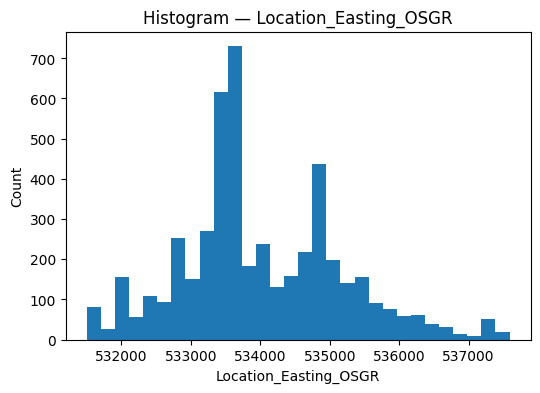

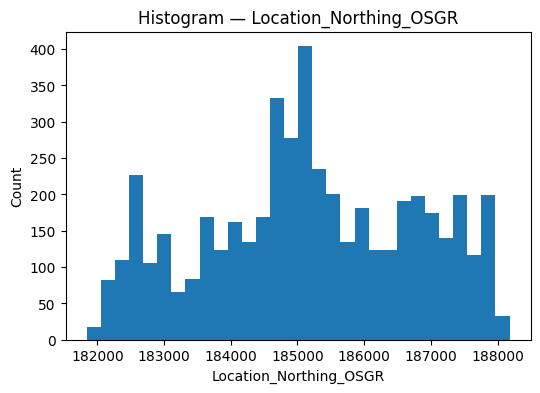

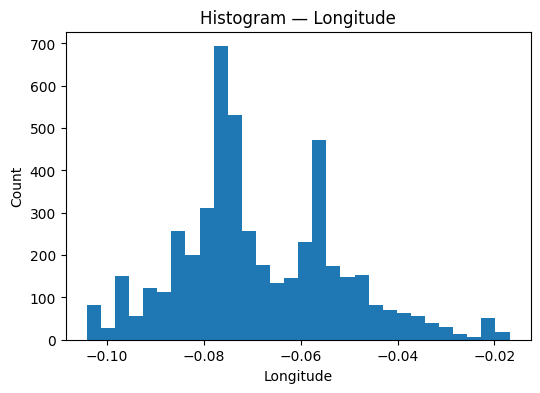

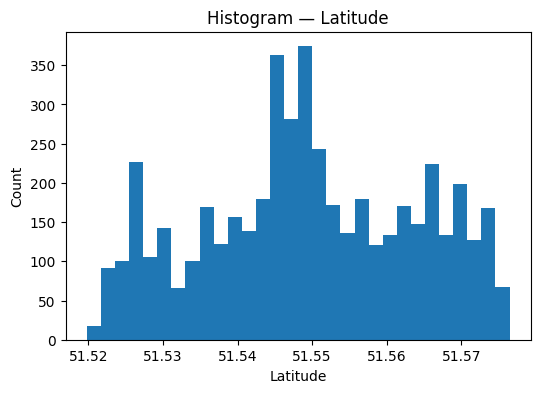

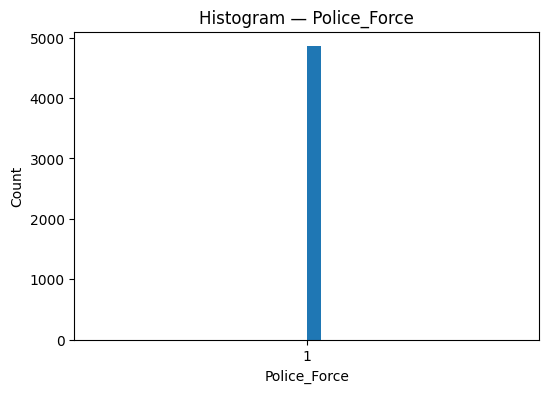

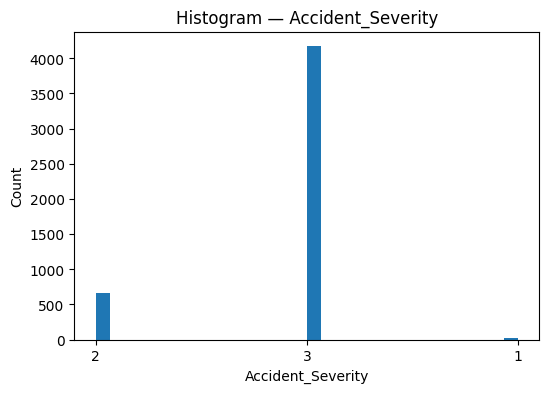

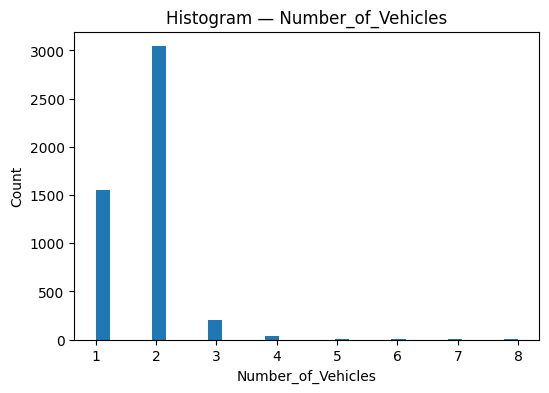

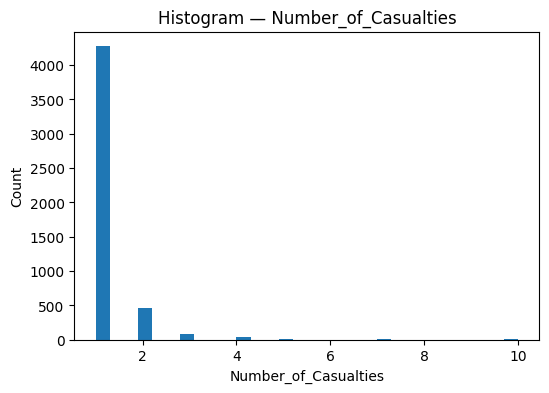

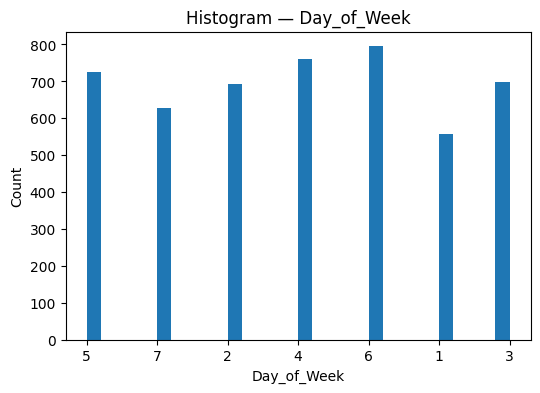

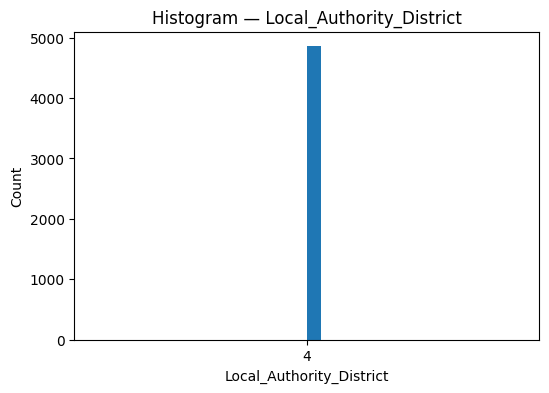

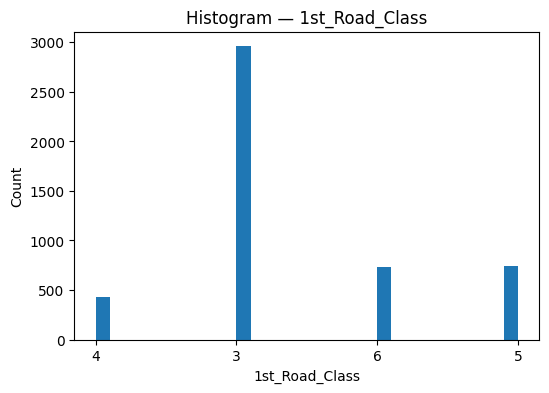

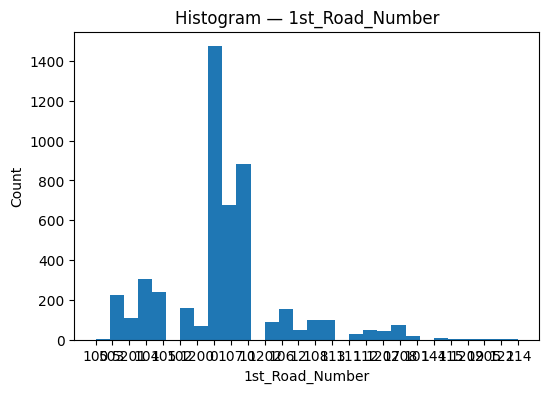

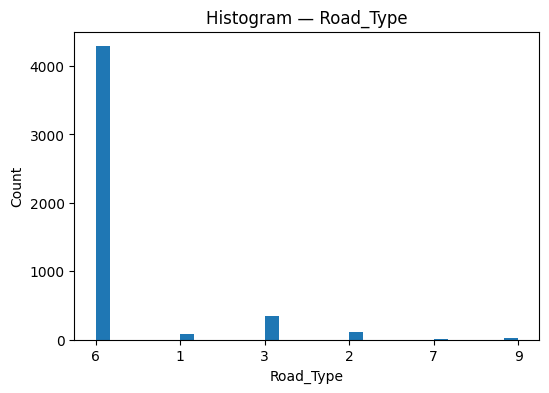

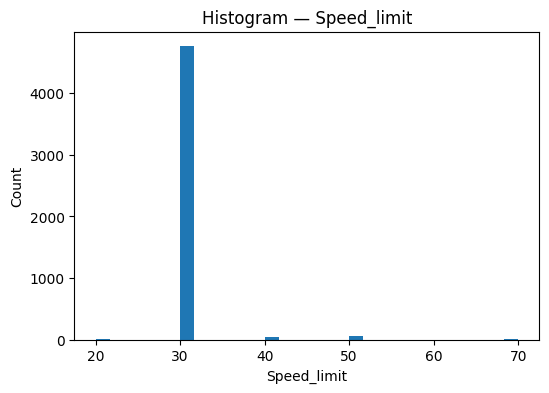

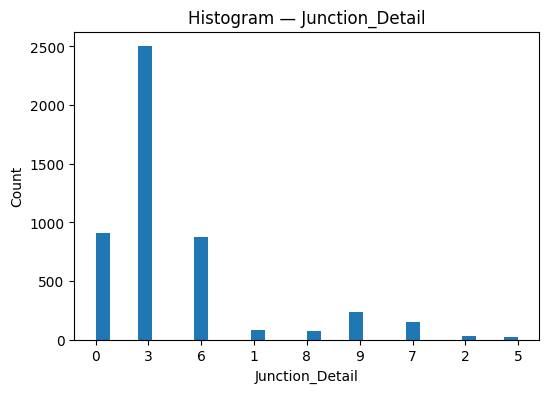

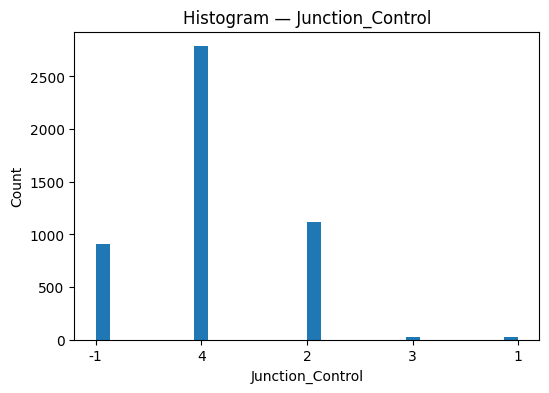

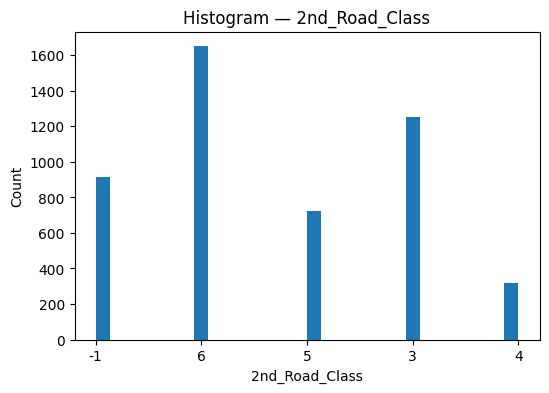

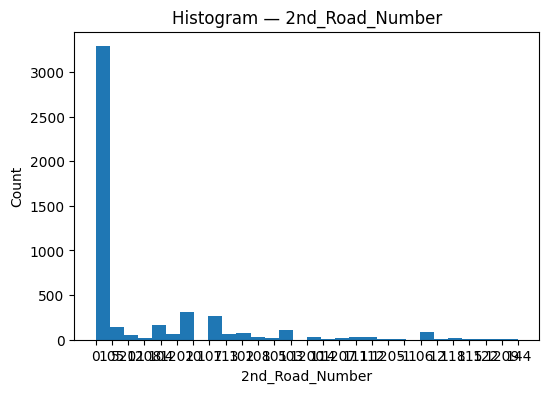

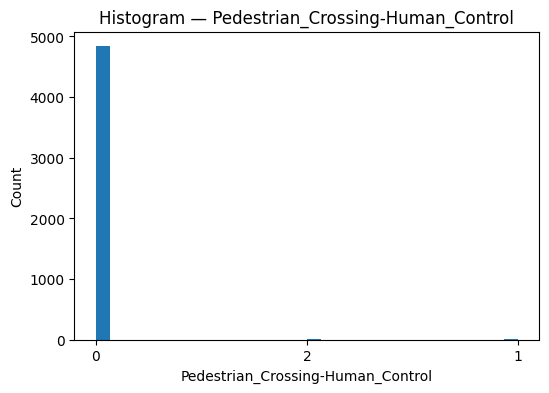

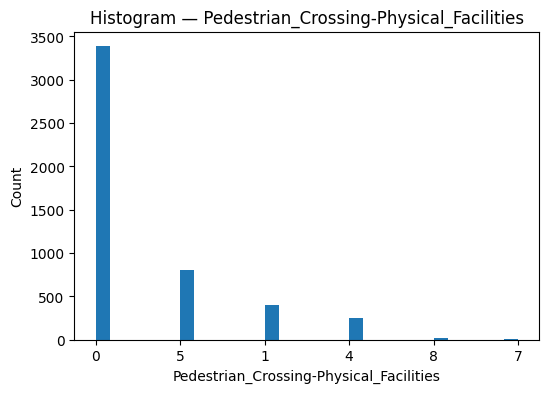

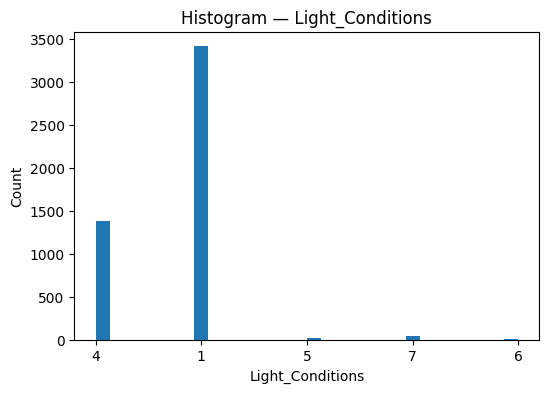

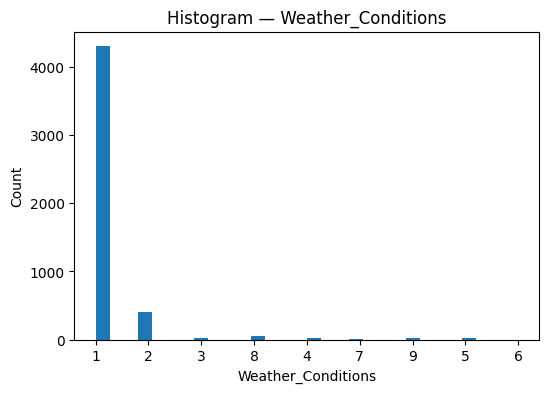

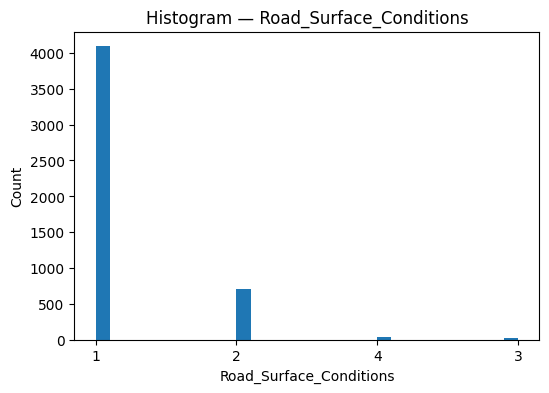

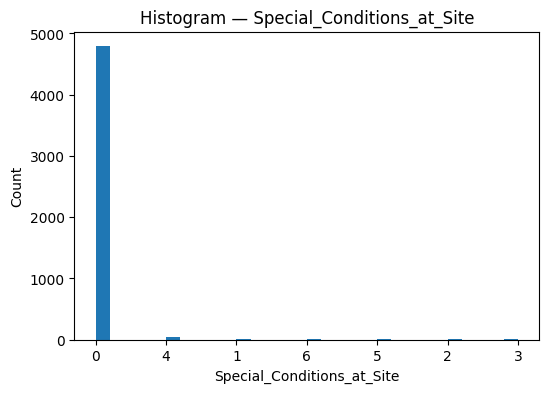

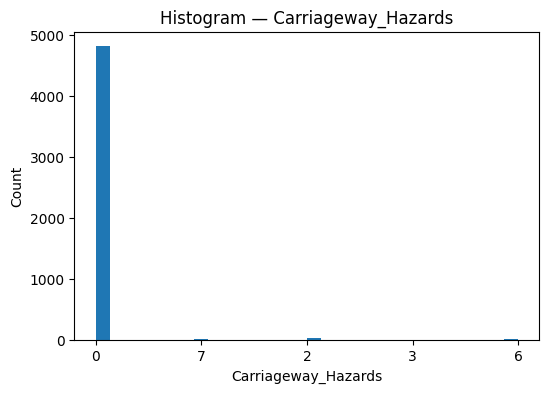

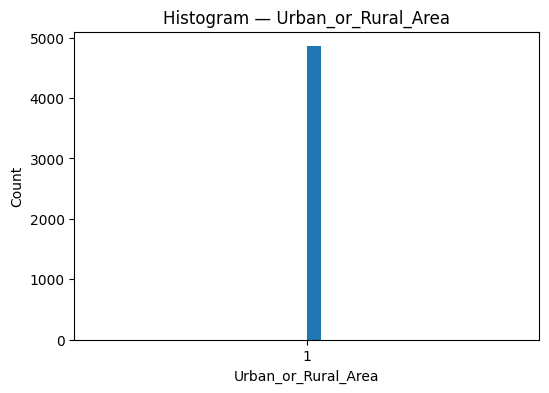

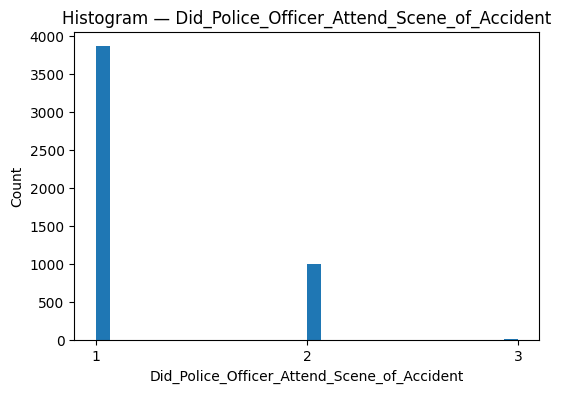

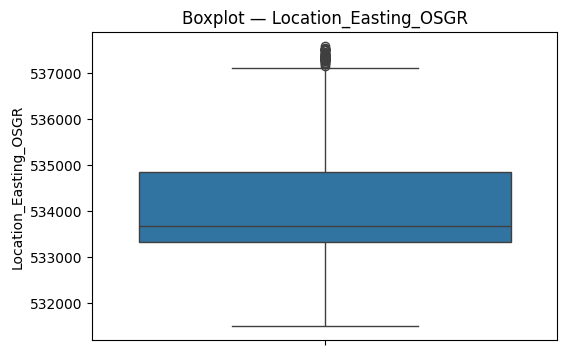

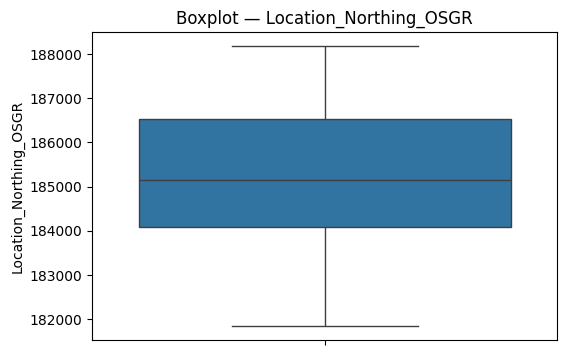

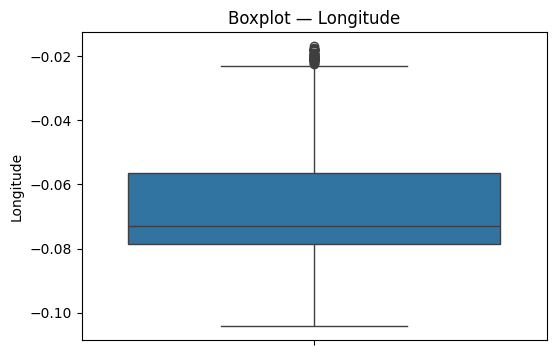

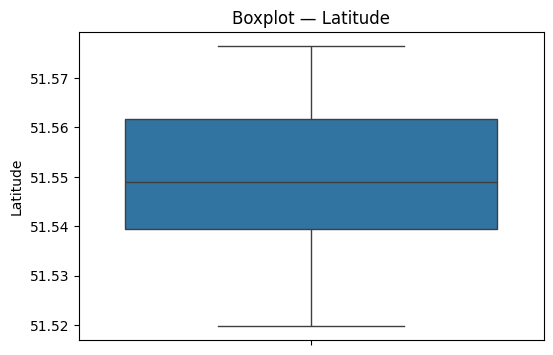

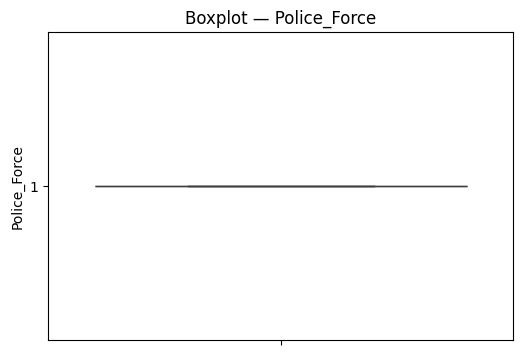

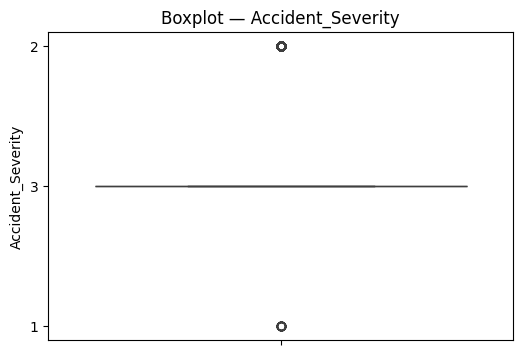

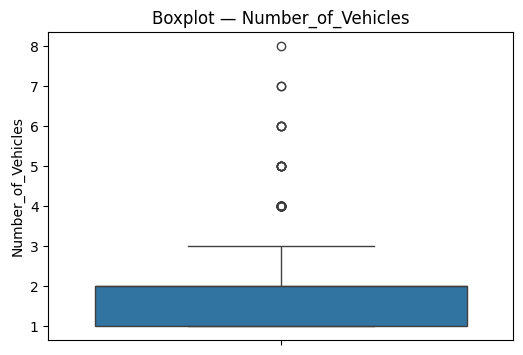

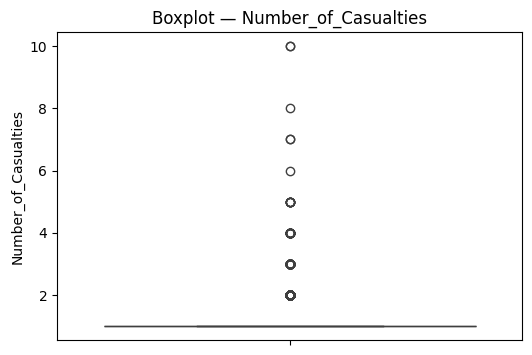

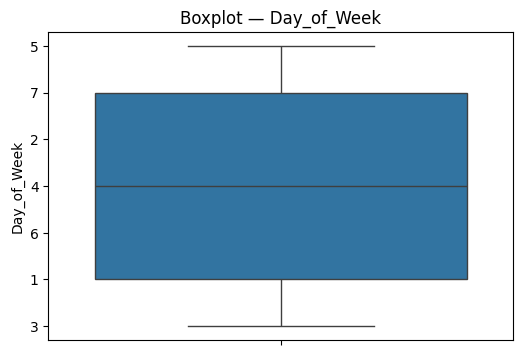

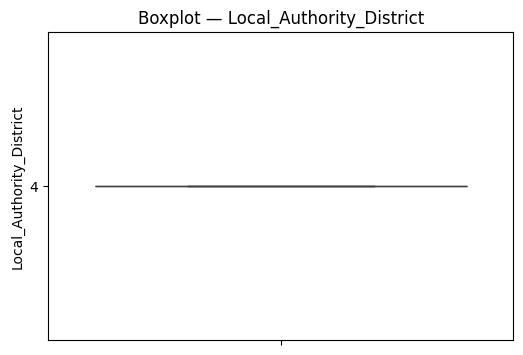

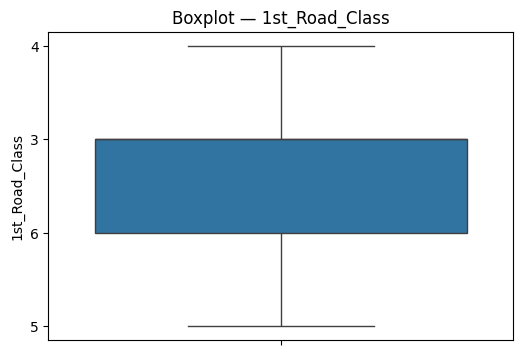

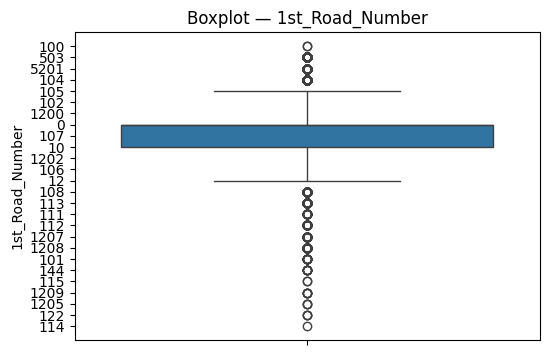

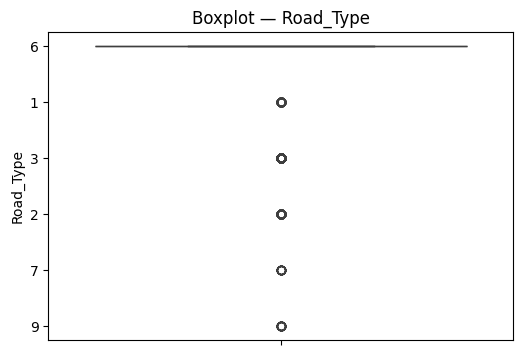

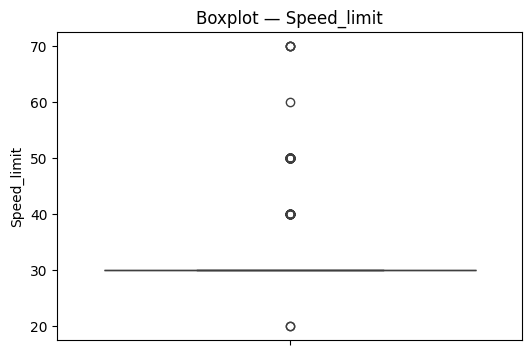

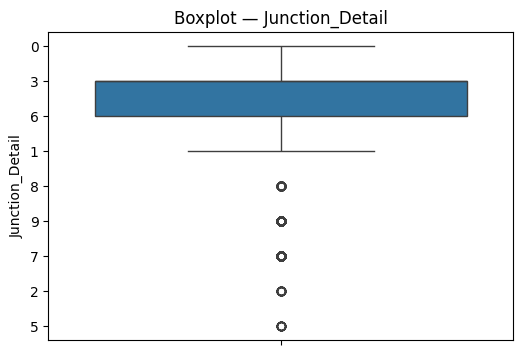

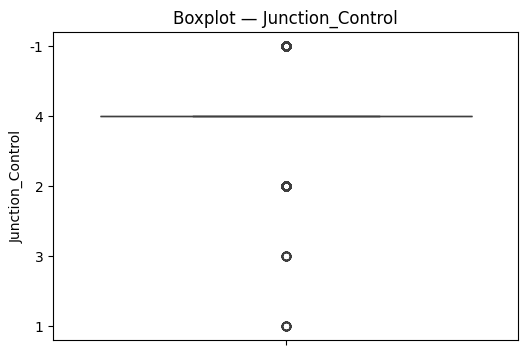

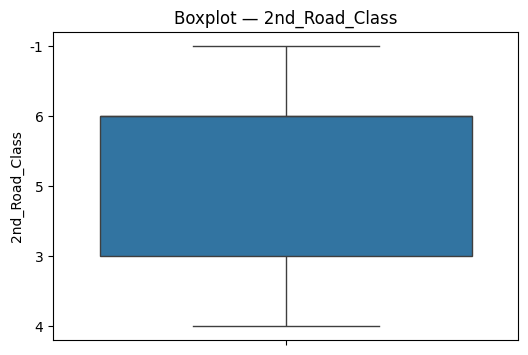

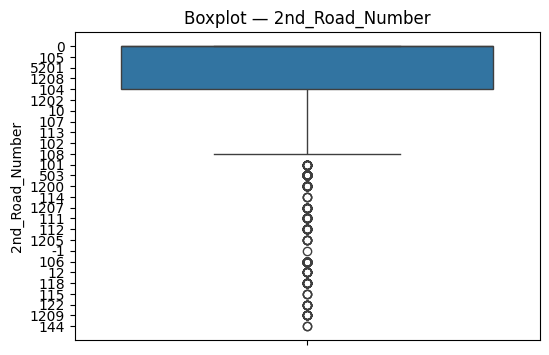

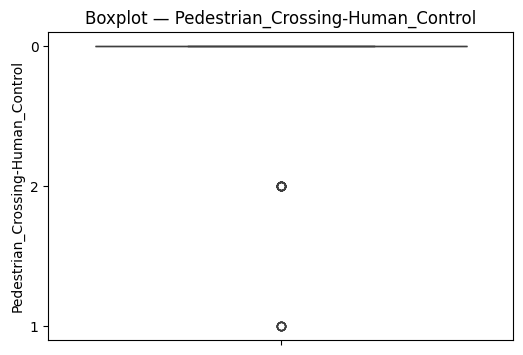

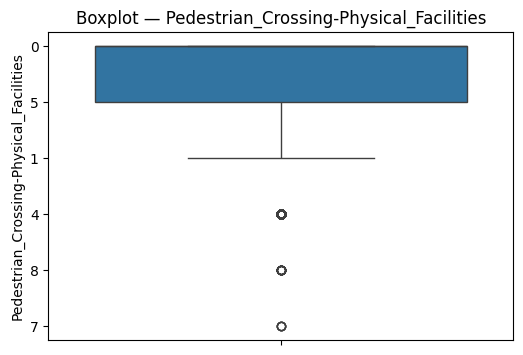

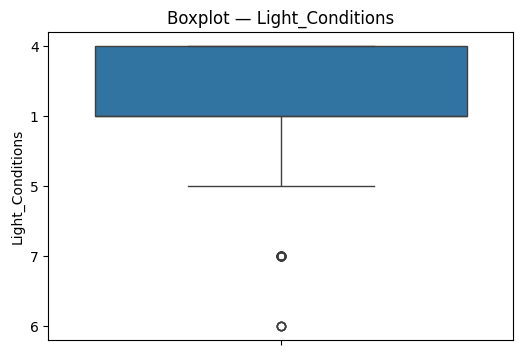

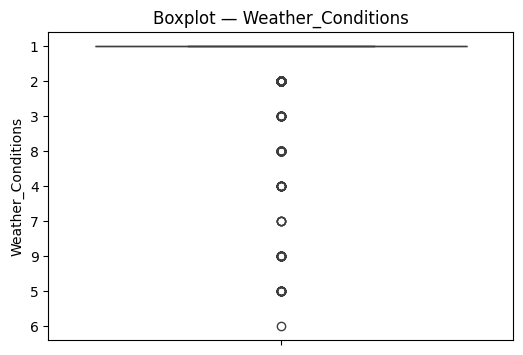

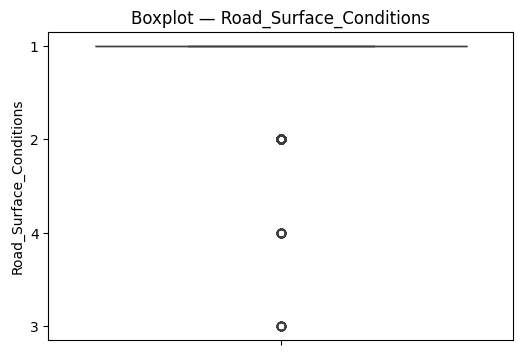

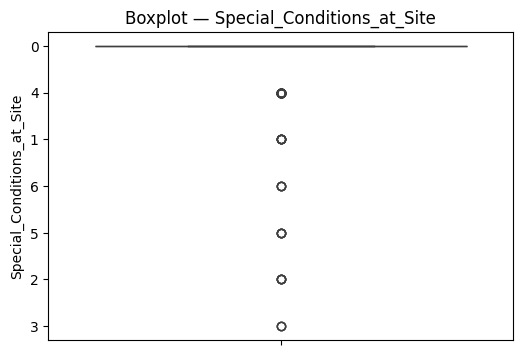

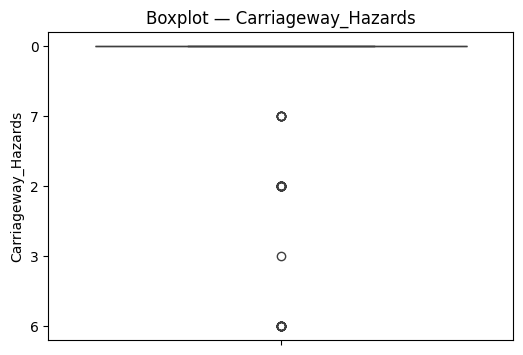

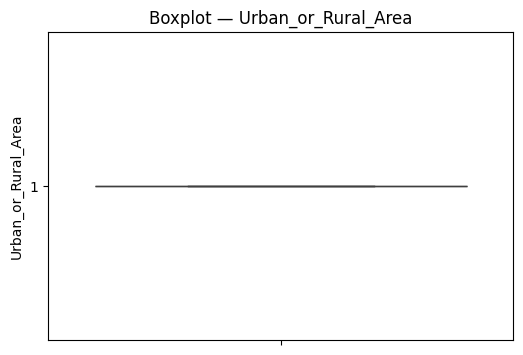

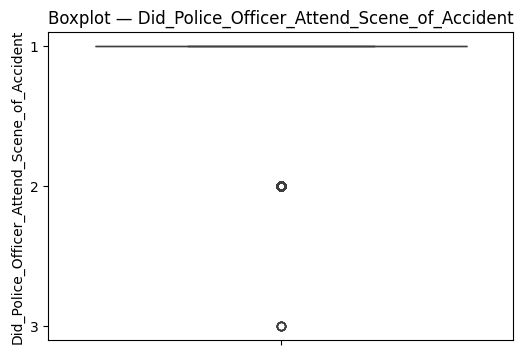

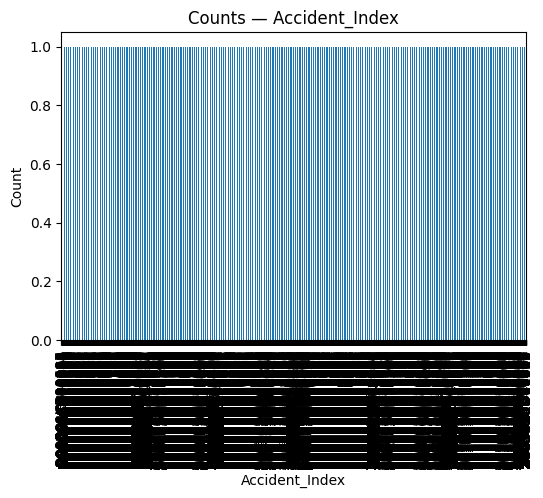

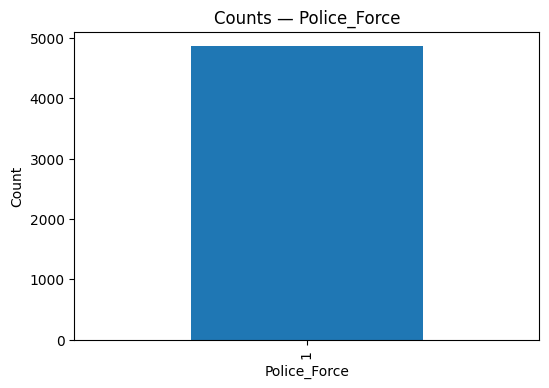

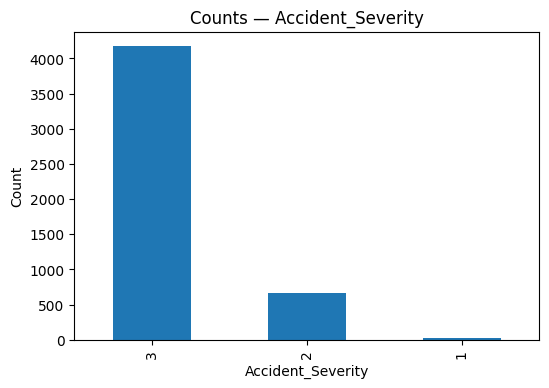

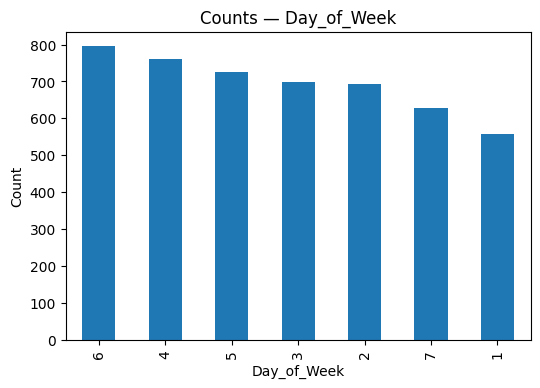

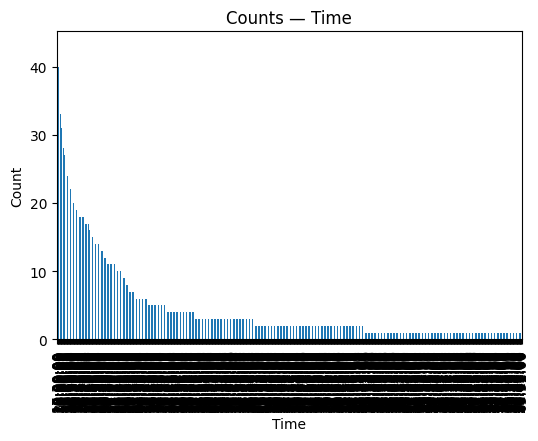

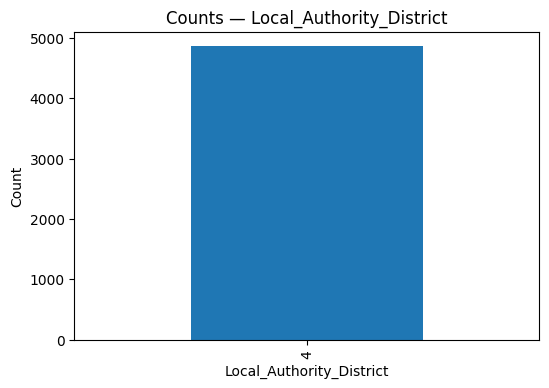

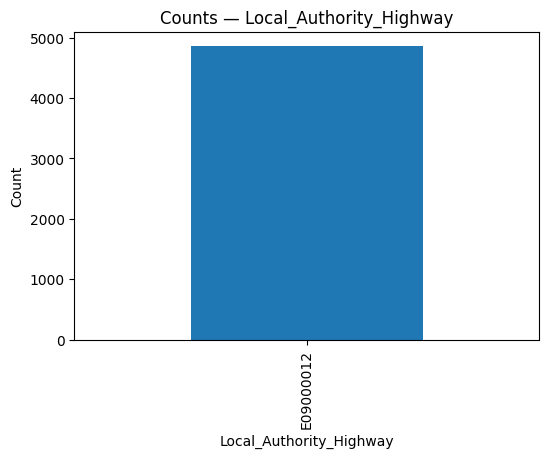

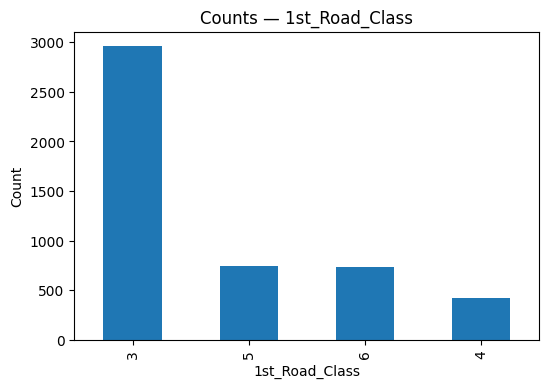

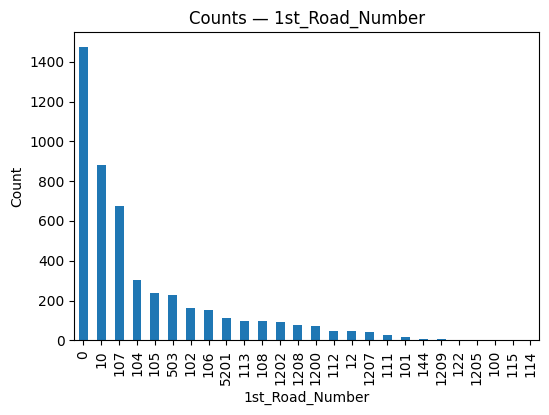

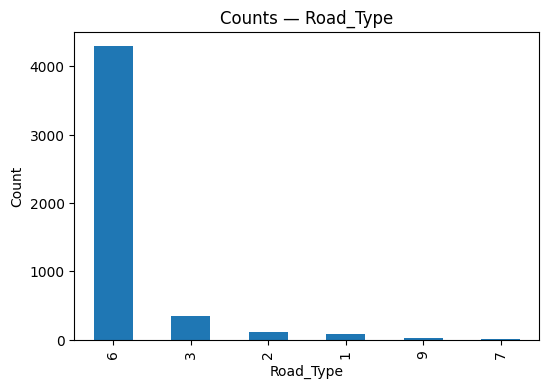

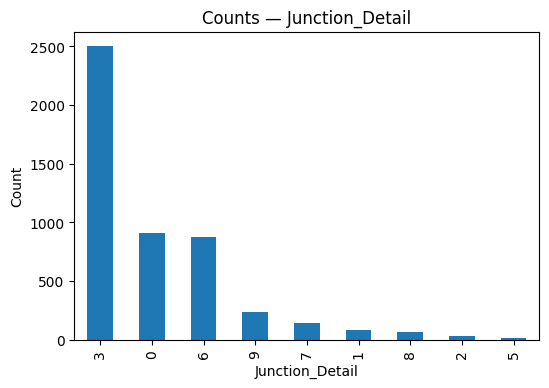

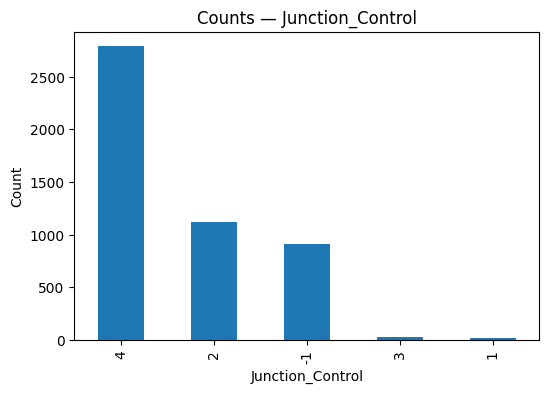

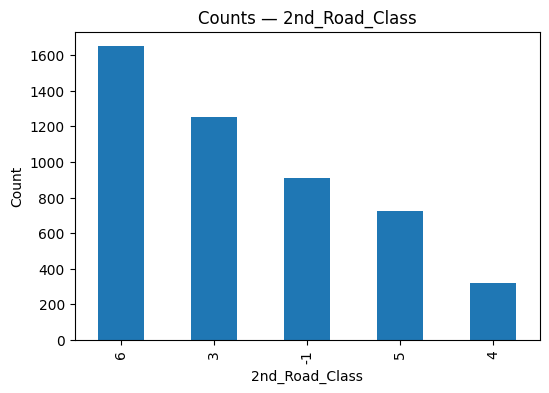

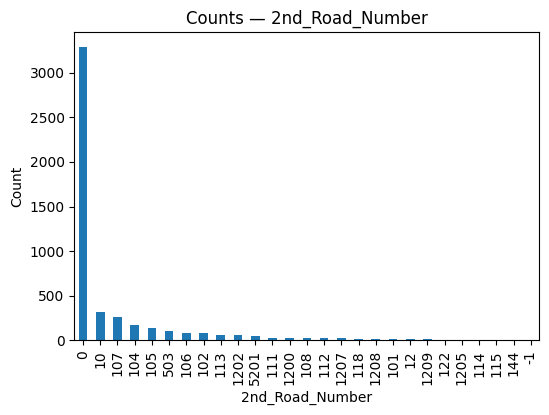

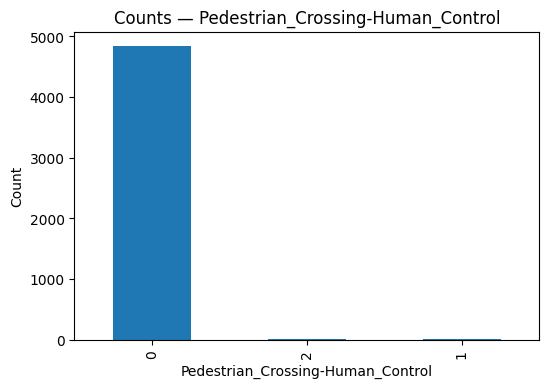

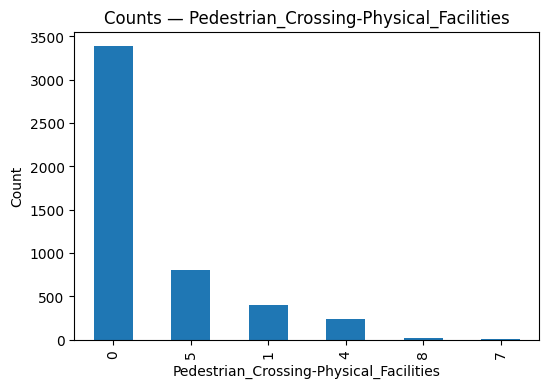

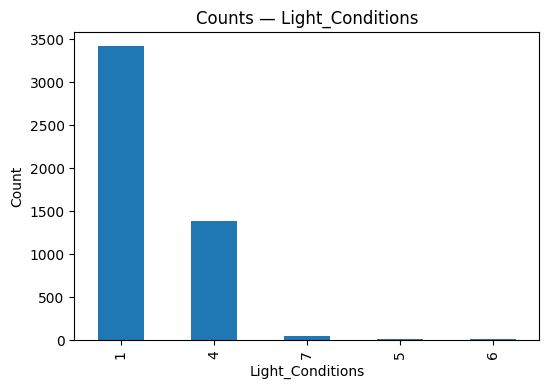

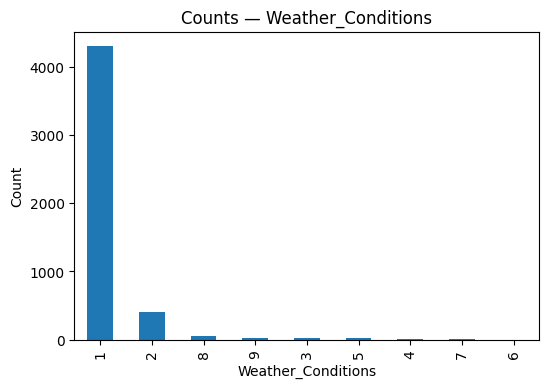

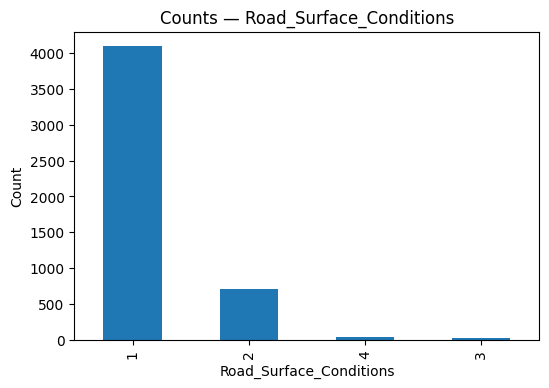

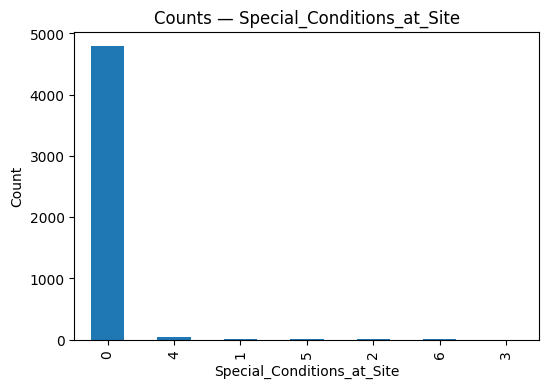

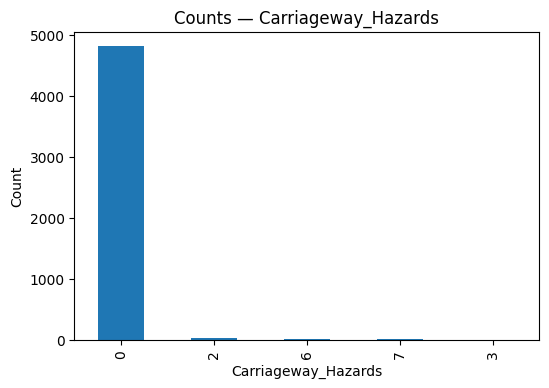

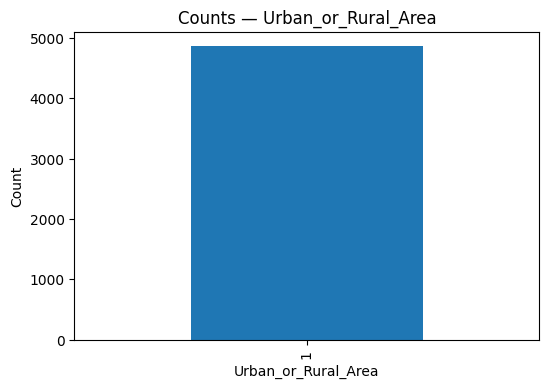

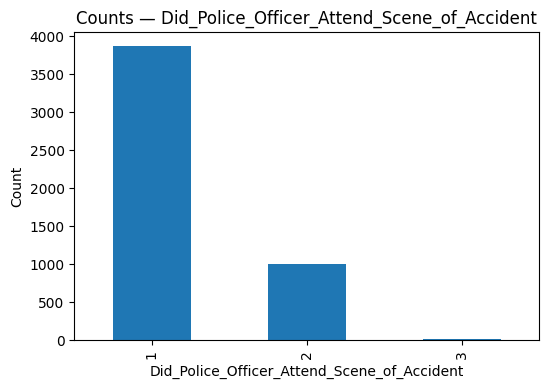

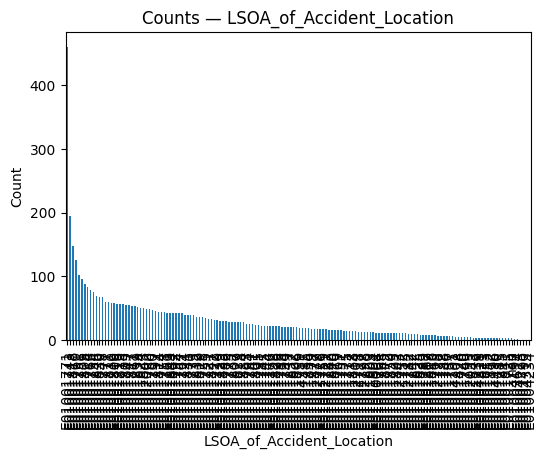

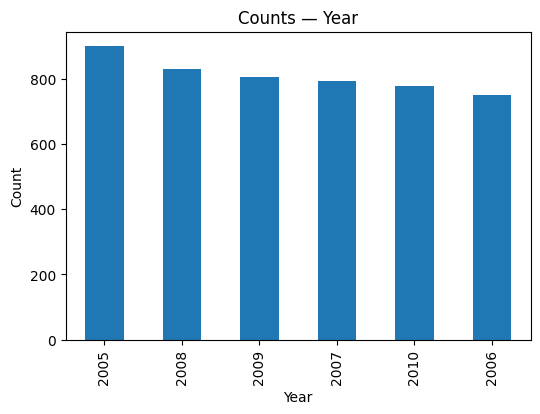

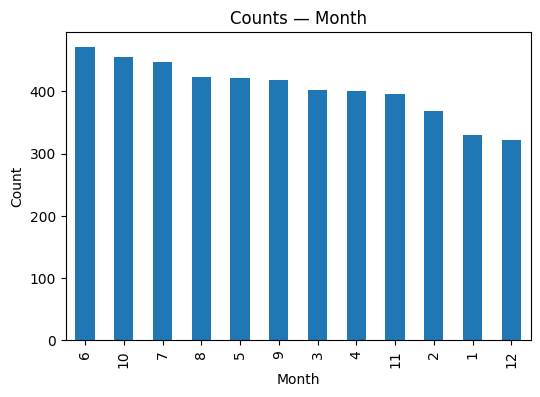

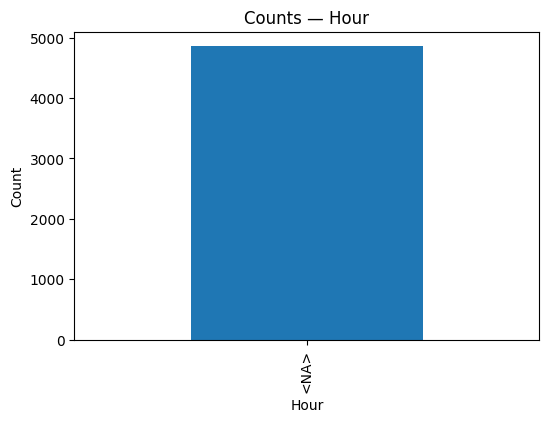

In [8]:

# Histograms for numeric
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Histogram — {col}')
    plt.xlabel(col); plt.ylabel('Count')
    plt.show()

# Boxplots for numeric
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot — {col}')
    plt.show()

# Bar counts for categoricals
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Counts — {col}')
    plt.xlabel(col); plt.ylabel('Count')
    plt.show()


## 6. Normalisation (z‑Score & Min‑Max)

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Convert all numeric-looking columns to float (ignore errors)
num = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop completely empty columns
num = num.dropna(axis=1, how='all')

# Handle missing numeric values temporarily (fill with median)
num = num.fillna(num.median())

# Now apply z-score and min-max scaling safely
zscored = num.apply(zscore)
minmax = (num - num.min()) / (num.max() - num.min())

print("✅ Z-score summary:")
display(zscored.describe().T)

print("✅ Min–Max summary:")
display(minmax.describe().T)


✅ Z-score summary:


,count,mean,std,min,25%,50%,75%,max
Location_Easting_OSGR,4857.0,-4.773378e-14,1.000103,-2.156354,-0.570717,-0.286336,0.739158,3.091762
Location_Northing_OSGR,4857.0,-7.386309e-15,1.000103,-2.109850,-0.697580,-0.022968,0.853396,1.887380
Longitude,4857.0,4.081561e-16,1.000103,-2.124335,-0.592374,-0.245162,0.744775,3.105168
Latitude,4857.0,-5.451371e-14,1.000103,-2.088501,-0.711189,-0.040499,0.852236,1.880440
Number_of_Vehicles,4857.0,-1.082565e-16,1.000103,-1.223423,-1.223423,0.410387,0.410387,10.213243
Number_of_Casualties,4857.0,1.086222e-16,1.000103,-0.305066,-0.305066,-0.305066,-0.305066,16.769655
Speed_limit,4857.0,-5.325047e-16,1.000103,-4.002211,-0.128409,-0.128409,-0.128409,15.366799
Year,4857.0,-5.935965e-14,1.000103,-1.428677,-0.847417,-0.266157,0.896364,1.477624
Month,4857.0,-5.851701e-17,1.000103,-1.684892,-0.776150,0.132591,0.738419,1.647160


✅ Min–Max summary:


,count,mean,std,min,25%,50%,75%,max
Location_Easting_OSGR,4857.0,0.410882,0.190564,0.0,0.302135,0.356322,0.551724,1.0
Location_Northing_OSGR,4857.0,0.527828,0.250199,0.0,0.353312,0.522082,0.741325,1.0
Longitude,4857.0,0.406221,0.191242,0.0,0.292946,0.359341,0.548639,1.0
Latitude,4857.0,0.526211,0.251982,0.0,0.347023,0.516007,0.740937,1.0
Number_of_Vehicles,4857.0,0.106974,0.087447,0.0,0.0,0.142857,0.142857,1.0
Number_of_Casualties,4857.0,0.017867,0.058572,0.0,0.0,0.0,0.0,1.0
Speed_limit,4857.0,0.20663,0.051634,0.0,0.2,0.2,0.2,1.0
Year,4857.0,0.491579,0.344116,0.0,0.2,0.4,0.8,1.0
Month,4857.0,0.505662,0.300146,0.0,0.272727,0.545455,0.727273,1.0


## 7. Missing Values — Where & How Much

Missing by count:


,count
Hour,4857
Location_Easting_OSGR,0
Accident_Index,0
Location_Northing_OSGR,0
Longitude,0
Police_Force,0
Latitude,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0


Missing by %:


,percent
Hour,100.0
Location_Easting_OSGR,0.0
Accident_Index,0.0
Location_Northing_OSGR,0.0
Longitude,0.0
Police_Force,0.0
Latitude,0.0
Number_of_Vehicles,0.0
Number_of_Casualties,0.0
Date,0.0


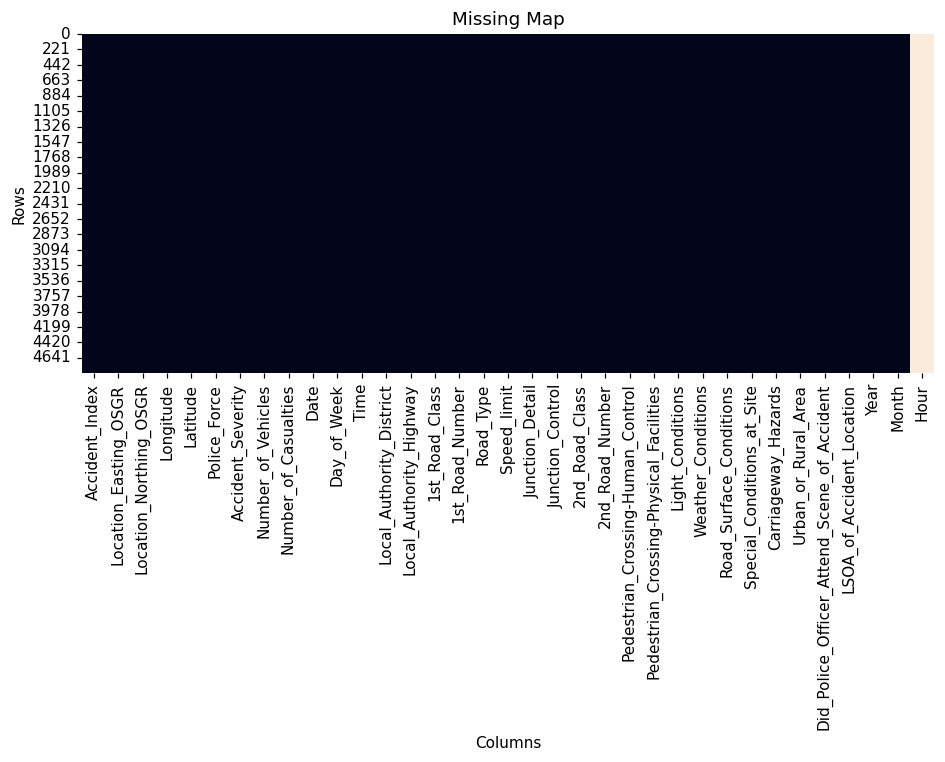

In [11]:

missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().sum()/len(df)).sort_values(ascending=False)
print('Missing by count:'); display(missing_count.to_frame('count'))
print('Missing by %:'); display((missing_pct*100).round(2).to_frame('percent'))

plt.figure(figsize=(10,4), dpi=110)
sns.heatmap(df.isna(), cbar=False)
plt.title('Missing Map')
plt.xlabel('Columns'); plt.ylabel('Rows')
plt.show()


## 8. Simple Imputation & Cleaned Copy

In [12]:

df_clean = df.copy()

# Numeric: median; Categorical: mode (first)
for c in df_clean.columns:
    if c in numeric_cols:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())
    else:
        mode_series = df_clean[c].mode()
        if not mode_series.empty:
            df_clean[c] = df_clean[c].fillna(mode_series.iloc[0])

print('After simple imputation:')
display(df_clean.isna().sum().sort_values(ascending=False).to_frame('remaining_missing'))


After simple imputation:


,remaining_missing
Hour,4857
Location_Easting_OSGR,0
Accident_Index,0
Location_Northing_OSGR,0
Longitude,0
Police_Force,0
Latitude,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0


## 9. Outliers — z‑Score and IQR

In [13]:

num_clean = df_clean[numeric_cols].copy()

# z-score method
Z = num_clean.apply(zscore)
mask_keep_z = (np.abs(Z) < 3).all(axis=1)
df_zscore_cleaned = df_clean[mask_keep_z]
print(f'z-score filtered: kept {df_zscore_cleaned.shape[0]} of {df_clean.shape[0]} rows')

# IQR method
mask_keep_iqr = pd.Series([True]*len(num_clean), index=num_clean.index)
for c in numeric_cols:
    Q1 = num_clean[c].quantile(0.25)
    Q3 = num_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    mask_keep_iqr &= (num_clean[c] >= lower) & (num_clean[c] <= upper)

df_iqr_cleaned = df_clean[mask_keep_iqr]
print(f'IQR filtered: kept {df_iqr_cleaned.shape[0]} of {df_clean.shape[0]} rows')


z-score filtered: kept 0 of 4857 rows
IQR filtered: kept 0 of 4857 rows


## 10. Correlation (Numeric Only)

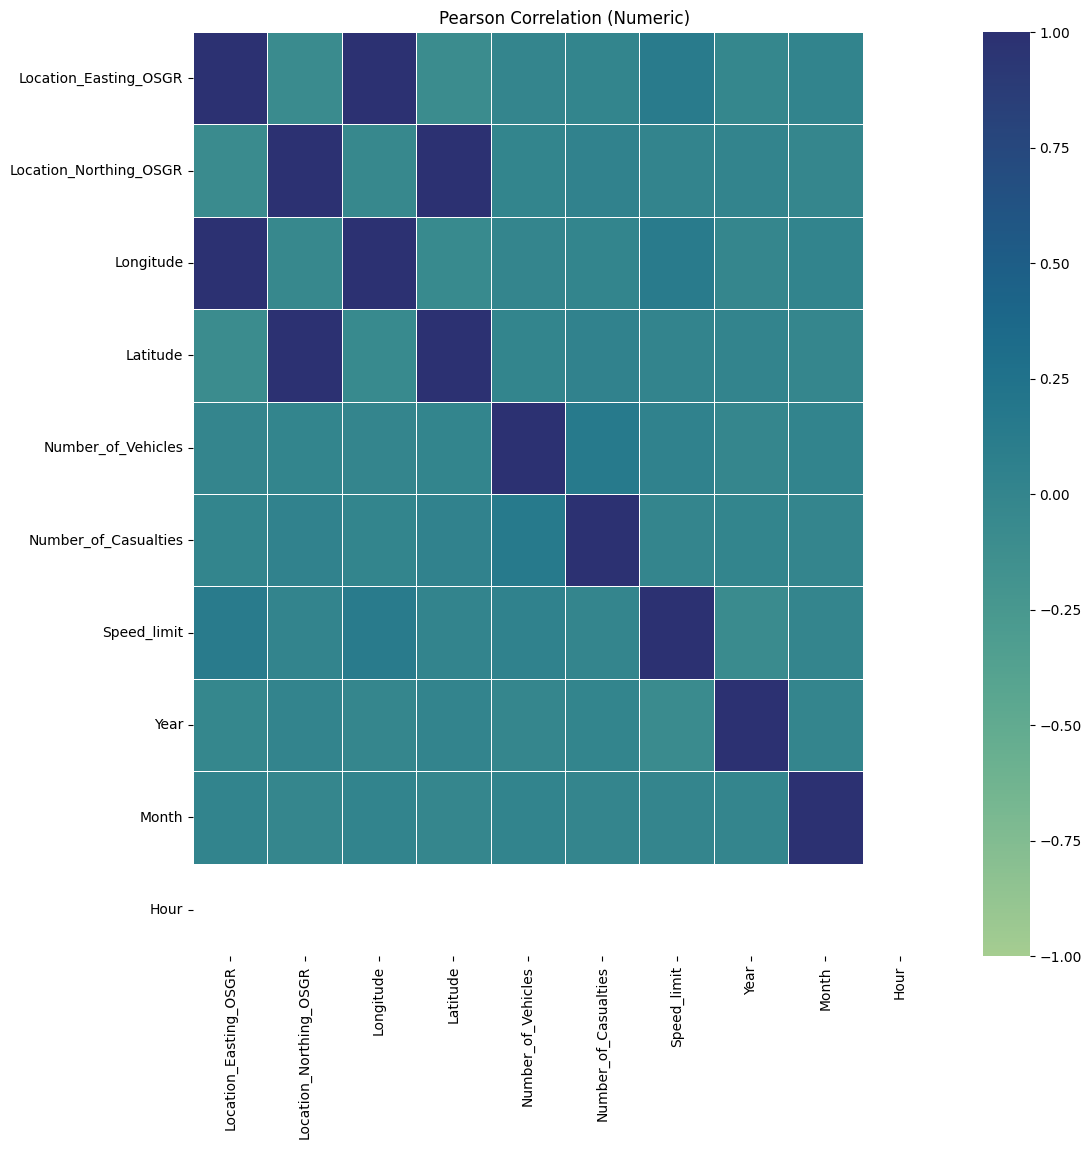

In [14]:

if len(numeric_cols) >= 2:
    corr = df_clean[numeric_cols].corr(method='pearson')
    plt.figure(figsize=(min(14, 1.2*len(numeric_cols)), min(12, 1.2*len(numeric_cols))))
    sns.heatmap(corr, vmin=-1, vmax=1, cmap='crest', annot=False, linewidths=.5)
    plt.title('Pearson Correlation (Numeric)')
    plt.show()
else:
    print('Not enough numeric columns for a correlation matrix.')


## 11. K‑Means on Numeric Features (with Silhouette & PCA Viz)

Silhouette by k: {2: np.float64(0.1952), 3: np.float64(0.2182), 4: np.float64(0.2278), 5: np.float64(0.2319), 6: np.float64(0.1895), 7: np.float64(0.1747), 8: np.float64(0.1631)}
Chosen k (max silhouette): 5 score: 0.2319


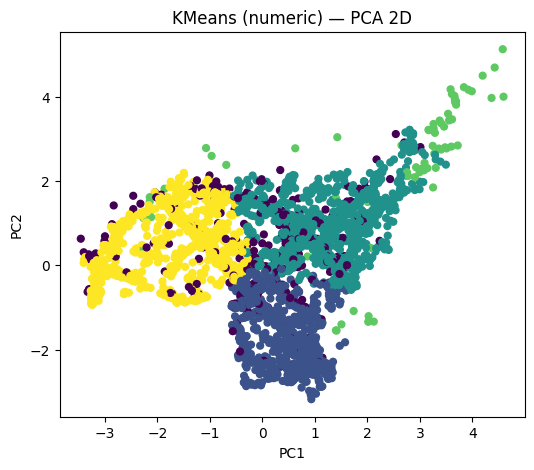

Cluster means (kept numeric features):


,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Number_of_Vehicles,Number_of_Casualties,Speed_limit,Year,Month
Cluster_K,,,,,,,,,
0,534159.713376,185461.687898,-0.066357,51.552046,2.251592,2.621019,30.000000,2007.429936,6.703822
1,533416.238286,183487.175368,-0.077822,51.534479,1.726238,1.061580,30.046854,2007.48929,6.541499
2,535241.695793,185182.640777,-0.050868,51.549280,1.666019,1.044013,30.000000,2007.43754,6.68932
3,535443.417722,185300.126582,-0.047917,51.550285,1.974684,1.164557,48.734177,2006.518987,6.683544
4,533158.287719,186905.115789,-0.080246,51.565254,1.738947,1.069474,30.042105,2007.505263,6.408421


In [16]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt

# 1) Start from your df; make a clean numeric-only view
df_clean = df.copy()

# numeric columns only
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# coerce any numeric-looking strings to numbers & replace infs with NaN
for c in numeric_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')
    df_clean[c].replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop numeric columns that are entirely NaN
num = df_clean[numeric_cols].dropna(axis=1, how='all')
kept_numeric = num.columns.tolist()

# 2) Impute missing numeric values with median
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(num)

# 3) Drop constant/near-constant columns (variance == 0)
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X_imp)
kept_mask = vt.get_support()
kept_cols_final = [col for col, keep in zip(kept_numeric, kept_mask) if keep]

# Guard: if nothing left after filtering, stop
if X_vt.shape[1] == 0:
    print("No usable numeric features after cleaning/variance filtering.")
else:
    # 4) Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_vt)

    # 5) Pick a safe k-range
    n_samples = X_scaled.shape[0]
    max_k = min(8, n_samples - 1)  # need at least k < n_samples
    best_k, best_score = None, -1
    scores = {}

    if max_k >= 2:
        for k in range(2, max_k + 1):
            # skip if k equals 1 or >= n_samples (invalid)
            if k >= n_samples:
                continue
            km = KMeans(n_clusters=k, n_init=20, random_state=42)
            labels = km.fit_predict(X_scaled)

            # Silhouette requires at least 2 distinct labels
            if len(np.unique(labels)) < 2:
                continue

            score = silhouette_score(X_scaled, labels)
            scores[k] = score
            if score > best_score:
                best_k, best_score = k, score

        if not scores:
            print("Could not compute silhouette (likely all points in one cluster). "
                  "Try different features or remove outliers.")
        else:
            print('Silhouette by k:', {k: round(v, 4) for k, v in scores.items()})
            print('Chosen k (max silhouette):', best_k, 'score:', round(best_score, 4))

            # 6) Final fit with best_k
            km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
            labels = km.fit_predict(X_scaled)

            # Attach cluster labels back to the original rows (index aligned)
            df_clustered = df_clean.copy()
            df_clustered['Cluster_K'] = labels

            # 7) 2D PCA plot (just for visual)
            pca = PCA(n_components=2, random_state=42)
            emb = pca.fit_transform(X_scaled)
            plt.figure(figsize=(6,5))
            plt.scatter(emb[:,0], emb[:,1], c=labels, s=24)
            plt.title('KMeans (numeric) — PCA 2D')
            plt.xlabel('PC1'); plt.ylabel('PC2')
            plt.show()

            # 8) Cluster means for the kept numeric features
            print("Cluster means (kept numeric features):")
            display(df_clustered.groupby('Cluster_K')[kept_cols_final].mean())
    else:
        print("Not enough rows to form at least 2 clusters.")


## 12. K‑Means on Binned (Categorical‑Style) Features

Binning columns: ['Location_Northing_OSGR', 'Location_Easting_OSGR', 'Month']


,Location_Northing_OSGR_BIN_Location_Northing_OSGR_L,Location_Northing_OSGR_BIN_Location_Northing_OSGR_M,Location_Northing_OSGR_BIN_Location_Northing_OSGR_H,Location_Easting_OSGR_BIN_Location_Easting_OSGR_L,Location_Easting_OSGR_BIN_Location_Easting_OSGR_M,Location_Easting_OSGR_BIN_Location_Easting_OSGR_H,Month_BIN_Month_L,Month_BIN_Month_M,Month_BIN_Month_H
Cluster,,,,,,,,,
0,0.089202,0.651643,0.259155,0.124883,0.760563,0.114554,1.000000,0.000000,0.000000
1,0.685412,0.000000,0.314588,0.996740,0.000000,0.003260,0.355338,0.255909,0.388753
2,0.103004,0.000000,0.896996,0.254292,0.741416,0.004292,0.000000,0.699571,0.300429
3,0.000000,1.000000,0.000000,0.182957,0.620301,0.196742,0.000000,1.000000,0.000000
4,0.113772,0.886228,0.000000,0.149701,0.663473,0.186826,0.000000,0.000000,1.000000


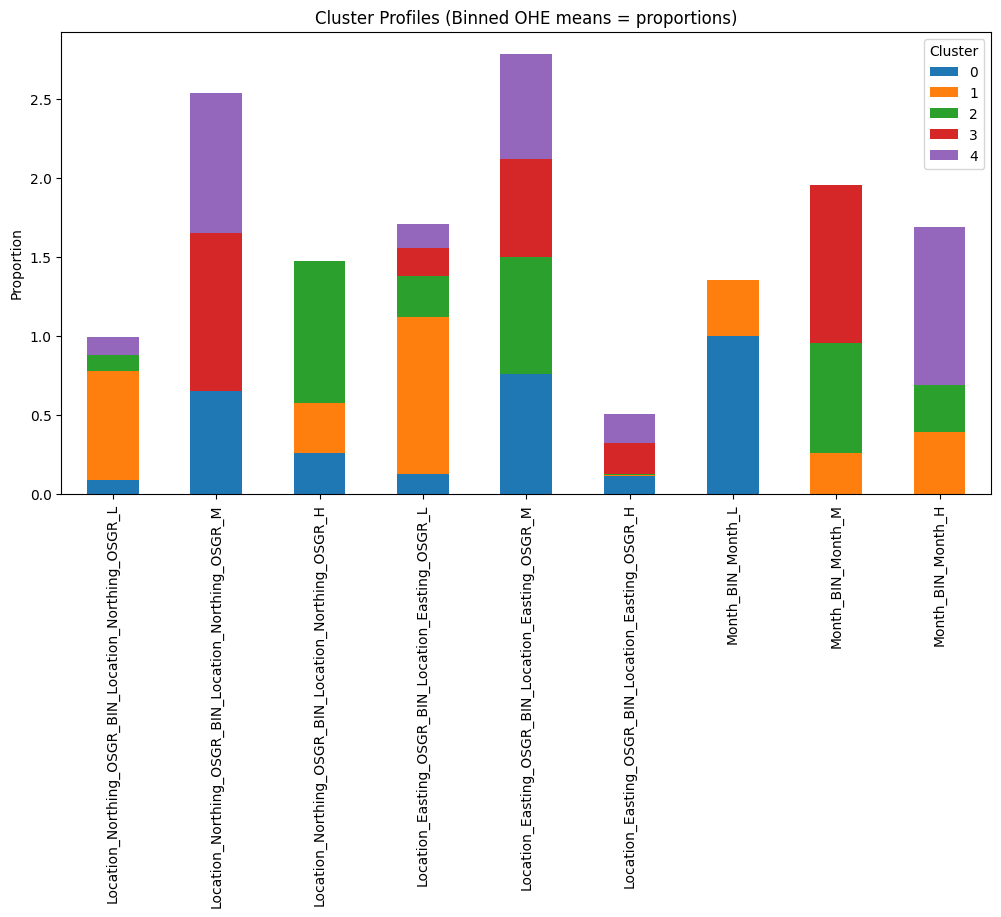

In [17]:

# Pick up to 2–3 numeric columns with the highest variance for binning
if len(numeric_cols) >= 2:
    var_sorted = pd.Series(df_clean[numeric_cols].var()).sort_values(ascending=False)
    pick_cols = var_sorted.index[:3].tolist()
    print('Binning columns:', pick_cols)

    binned = pd.DataFrame(index=df_clean.index)
    for c in pick_cols:
        binned[f'{c}_BIN'] = pd.cut(df_clean[c], bins=3, labels=[f'{c}_L', f'{c}_M', f'{c}_H'])

    # One-hot
    binned_ohe = pd.get_dummies(binned, drop_first=False)

    # KMeans on OHE (use 3 clusters as a readable default)
    k_cat = min(5, max(2, len(df_clean)//10))  # heuristic
    km2 = KMeans(n_clusters=k_cat, n_init=20, random_state=42)
    labels2 = km2.fit_predict(binned_ohe.values)
    df_cat_clustered = df_clean.copy()
    df_cat_clustered['Cluster_BIN'] = labels2

    # Interpret clusters: means across OHE columns (proportions)
    interpret = pd.concat([binned_ohe, pd.Series(labels2, name='Cluster')], axis=1)
    cluster_profiles = interpret.groupby('Cluster').mean()
    display(cluster_profiles)

    # Stacked bar of the average OHE per cluster
    (cluster_profiles.T).plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title('Cluster Profiles (Binned OHE means = proportions)')
    plt.ylabel('Proportion')
    plt.show()
else:
    print('Not enough numeric columns to perform binning-based clustering.')
    #
